# Stage 06-A: Text-Conditioned Cross-Attention Fusion

**Motivation:** MIL attention (05a) scores image pairs purely based on image features — it has
no idea what the _text_ is asking. Cross-attention fixes this: the PhoBERT CLS vector becomes
the query that selects which image pairs are most relevant _to this specific claim_.

## Architecture

```
PhoBERT CLS [B, 768]
         │
   TextProjector: Linear[768→128] + LN + ReLU
   h_t [B, 128]  →  query [B, 1, 128]
         │
         ├──────────────────────────────────────────────┐
         │                                              │
         │  COOLANT image_aligned_clip [B, max_pairs, 64]│
         │         ▼                                    │
         │  ImageProjector: Linear[64→128]+LN+ReLU      │
         │  K, V: [B, max_pairs, 128]                   │
         │                                              │
         └──── Cross-Attention (4 heads, batch_first) ──┘
                   Q = text_proj  [B, 1, 128]
                   K = V = image  [B, P, 128]
                   key_padding_mask = True for padded positions
                        ▼
              context [B, 1, 128] → squeeze → [B, 128]
                        ▼
              Residual + LayerNorm: context + h_t  [B, 128]
                        ▼
              cat(h_t [128], context [128])  →  [B, 256]
                        ▼
              Dropout(0.3) + Linear[256→3]
                        ▼
              (Real=0, Fake=1, NEI=2)
```

## Key Difference vs 05a (MIL Attention)

|                  | 05a MIL Attention              | 06a Cross-Attention                |
| ---------------- | ------------------------------ | ---------------------------------- |
| Query            | learned global vector `v`      | PhoBERT CLS (claim-specific)       |
| Scoring          | `v^T · tanh(W·img_i)`          | scaled dot-product Q·K^T           |
| Text involvement | none (images score themselves) | text directly conditions selection |
| Multi-head       | no                             | yes (4 heads)                      |

**Inputs:**

-   `training/stage05a_cache/stage05a_{split}.h5` — reuses 05a cache (no rebuild needed)

**Outputs:**

-   `training/checkpoints_stage06a/{timestamp}_cross-attn_phobert768-coolant64_3cls_bs{B}_lr{lr}/best_model.pth`
-   `training/stage06a_results/{timestamp}_results.json`


In [1]:
# ─── Environment Setup (do not edit) ─────────────────────────────────────────
import os, sys
from pathlib import Path


def _detect_platform():
    try:
        import google.colab

        return "colab", False
    except ImportError:
        pass
    if Path("/workspace").exists() and os.environ.get("VAST_CONTAINERLABEL"):
        return "vastai", False
    if Path("/workspace").exists():
        return "vastai", True
    if sys.platform == "win32":
        return "windows", False
    if sys.platform == "darwin":
        return "mac", False
    return None, True


PLATFORM, _uncertain = _detect_platform()
if PLATFORM == "colab":
    from google.colab import drive

    drive.mount("/content/drive")

try:
    _nb_path = Path(__file__).resolve()
except NameError:
    _nb_path = Path.cwd()

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Thesis_Final/fake-news-detection")
    if PLATFORM == "colab"
    else _nb_path.parents[1]
)
sys.path.insert(0, str(PROJECT_ROOT))

_env_map = {
    "colab": PROJECT_ROOT / ".env.colab",
    "vastai": PROJECT_ROOT / ".env.vastai",
    "windows": PROJECT_ROOT / ".env.windows",
    "mac": PROJECT_ROOT / ".env.mac",
}
_env_file = _env_map.get(PLATFORM, PROJECT_ROOT / ".env")
if not _env_file.exists():
    _env_file = PROJECT_ROOT / ".env"

from dotenv import load_dotenv

load_dotenv(_env_file, override=True)
from src.utils.env_utils import get_data_root

DATA_ROOT = get_data_root()

print(f"Platform : {PLATFORM}  Project: {PROJECT_ROOT}")
print(f"DATA_ROOT: {DATA_ROOT}  exists={DATA_ROOT.exists()}")

Platform : mac  Project: /Users/haila/My File/projects/fake-new-detection
DATA_ROOT: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis  exists=True


## Step 1: Configuration


In [2]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "pipeline" else Path.cwd()
try:
    from dotenv import load_dotenv

    load_dotenv(PROJECT_ROOT / ".env", override=False)
except ImportError:
    pass
DATA_ROOT = (
    Path(os.environ["DATA_ROOT"]) if os.environ.get("DATA_ROOT") else PROJECT_ROOT
)

CONFIG = {
    "paths": {
        "project_root": PROJECT_ROOT,
        # Reuse Stage 05a MIL cache — text[768] + images[max_pairs,64] + pair_counts
        "stage05a_cache_dir": DATA_ROOT / "training" / "stage05a_cache",
        "stage39_checkpoint_root": DATA_ROOT / "training" / "checkpoints_vifactcheck",
        "stage39_manifest": None,  # None = auto-detect newest
        "checkpoint_root": DATA_ROOT / "training" / "checkpoints_stage06a",
        "results_dir": DATA_ROOT / "training" / "stage06a_results",
        "mlflow_dir": DATA_ROOT / "mlruns",
    },
    "model": {
        "arch_tag": "cross-attn_phobert768-coolant64_3cls",
        "text_dim": 768,  # PhoBERT CLS
        "image_dim": 64,  # COOLANT image_aligned_clip
        "proj_dim": 128,  # shared projection dimension for Q/K/V
        "num_heads": 4,  # multi-head cross-attention
        "num_classes": 3,  # Real=0, Fake=1, NEI=2
        "dropout": 0.3,
        "max_pairs": 32,  # must match stage05a_cache max_pairs
    },
    "training": {
        "batch_size": 32,
        "max_epochs": 40,
        "patience": 8,
        "lr": 3e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.1,
        "grad_clip": 1.0,
        "onecycle_pct_start": 0.05,
        "seed": 42,
    },
    "mlflow": {"experiment_name": "stage06a-cross-attention-fusion"},
    "safety": {
        "smoke_test": False,
        "smoke_batches": 3,
        "smoke_epochs": 2,
    },
}

CONFIG["paths"]["checkpoint_root"].mkdir(parents=True, exist_ok=True)
CONFIG["paths"]["results_dir"].mkdir(parents=True, exist_ok=True)

print(f'Checkpoint root : {CONFIG["paths"]["checkpoint_root"]}')
print(f'Stage05a cache  : {CONFIG["paths"]["stage05a_cache_dir"]}')
print(f'Arch tag        : {CONFIG["model"]["arch_tag"]}')

Checkpoint root : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_stage06a
Stage05a cache  : /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage05a_cache
Arch tag        : cross-attn_phobert768-coolant64_3cls


## Step 2: Dependencies, Device, Seed


In [3]:
import importlib, sys, random, json, gc
from datetime import datetime

_required = [
    ("torch", "torch"),
    ("h5py", "h5py"),
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("tqdm", "tqdm"),
    ("sklearn", "scikit-learn"),
    ("mlflow", "mlflow"),
]
_missing = [pkg for mod, pkg in _required if importlib.util.find_spec(mod) is None]
if _missing:
    raise RuntimeError(
        f'Missing packages: {_missing}. Install with pip install {" ".join(_missing)}'
    )

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def select_device():
    from src.utils.device import get_device

    return get_device()


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    print(f"Seed: {seed}")


device = select_device()
seed_everything(CONFIG["training"]["seed"])
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Seed: 42
Device: mps
PyTorch: 2.12.0


## Step 3: Validate Stage 05a Cache

Reuses `stage05a_cache` built by `05a_mil_attention_fusion.ipynb`.
No cache rebuilding needed — cross-attention uses the same `[text, images, pair_counts]` inputs.


In [4]:
cache_dir = CONFIG["paths"]["stage05a_cache_dir"]

for split in ("train", "dev", "test"):
    p = cache_dir / f"stage05a_{split}.h5"
    if not p.exists():
        raise FileNotFoundError(
            f"Stage 05a cache missing: {p}\n"
            "Run 05a_mil_attention_fusion.ipynb first (Step 4 builds the cache)."
        )
    with h5py.File(p, "r") as f:
        n = f.attrs["n_articles"]
        mp = f.attrs["max_pairs"]
        hist = f.attrs.get("label_hist", "?")
        print(f"  [{split}] n={n}  max_pairs={mp}  label_hist={hist}")
        if int(mp) != CONFIG["model"]["max_pairs"]:
            raise ValueError(
                f'max_pairs mismatch: cache has {mp} but CONFIG has {CONFIG["model"]["max_pairs"]}. '
                'Update CONFIG["model"]["max_pairs"] to match.'
            )

print("\u2705 Stage 05a cache validated.")

  [train] n=5062  max_pairs=32  label_hist=[1751, 1658, 1653]
  [dev] n=723  max_pairs=32  label_hist=[256, 244, 223]
  [test] n=1447  max_pairs=32  label_hist=[508, 468, 471]
✅ Stage 05a cache validated.


## Step 4: Dataset and DataLoaders


In [5]:
class MILArticleDataset(Dataset):
    """Loads stage05a cache: text[768], images[max_pairs,64], pair_counts, label."""

    def __init__(self, h5_path):
        with h5py.File(h5_path, "r") as f:
            self.text_features = f["text_features"][:].astype(np.float32)  # [N, 768]
            self.image_features = f["image_features"][:].astype(
                np.float32
            )  # [N, max_pairs, 64]
            self.pair_counts = f["pair_counts"][:].astype(np.int32)  # [N]
            self.labels = f["labels"][:].astype(np.int64)  # [N]
            self.max_pairs = int(f.attrs["max_pairs"])
        print(
            f"  [{Path(h5_path).stem}] {len(self.labels)} articles, max_pairs={self.max_pairs}"
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.text_features[idx]),
            torch.from_numpy(self.image_features[idx]),
            int(self.pair_counts[idx]),
            int(self.labels[idx]),
        )


def _collate(batch):
    texts, images, counts, labels = zip(*batch)
    return (
        torch.stack(texts),
        torch.stack(images),
        torch.tensor(counts),
        torch.tensor(labels),
    )


datasets = {
    s: MILArticleDataset(cache_dir / f"stage05a_{s}.h5")
    for s in ("train", "dev", "test")
}
bs = CONFIG["training"]["batch_size"]
loaders = {
    "train": DataLoader(
        datasets["train"],
        batch_size=bs,
        shuffle=True,
        num_workers=0,
        collate_fn=_collate,
    ),
    "dev": DataLoader(
        datasets["dev"],
        batch_size=bs,
        shuffle=False,
        num_workers=0,
        collate_fn=_collate,
    ),
    "test": DataLoader(
        datasets["test"],
        batch_size=bs,
        shuffle=False,
        num_workers=0,
        collate_fn=_collate,
    ),
}

if CONFIG["safety"]["smoke_test"]:
    from itertools import islice

    class _Smoke:
        def __init__(self, l, n):
            self._l, self._n = l, n

        def __iter__(self):
            return islice(iter(self._l), self._n)

        def __len__(self):
            return min(self._n, len(self._l))

    loaders = {
        k: _Smoke(v, CONFIG["safety"]["smoke_batches"]) for k, v in loaders.items()
    }
    print(f'SMOKE: {CONFIG["safety"]["smoke_batches"]} batches/split')

_t, _img, _cnt, _lbl = next(
    iter(DataLoader(datasets["train"], batch_size=4, collate_fn=_collate))
)
print(
    f"Batch: text={tuple(_t.shape)}  image={tuple(_img.shape)}  counts={_cnt.tolist()}  labels={_lbl.tolist()}"
)
print(
    f'Train label hist: {np.bincount(datasets["train"].labels, minlength=3).tolist()}'
)

  [stage05a_train] 5062 articles, max_pairs=32
  [stage05a_dev] 723 articles, max_pairs=32
  [stage05a_test] 1447 articles, max_pairs=32
Batch: text=(4, 768)  image=(4, 32, 64)  counts=[0, 0, 2, 5]  labels=[0, 0, 1, 2]
Train label hist: [1751, 1658, 1653]


## Step 5: CrossAttentionFusionHead

PhoBERT text projects to a **query** that directly conditions which image pairs receive attention.
Uses `nn.MultiheadAttention` (batch_first=True) with a key padding mask to ignore padded pairs.
A residual connection over the cross-attended context stabilises training.


In [6]:
class CrossAttentionFusionHead(nn.Module):
    """
    Text-conditioned cross-attention over image pairs.

    Inputs:
        text_feat   [B, 768]           — frozen PhoBERT CLS (Stage 3.9)
        image_feat  [B, max_pairs, 64] — frozen COOLANT image_aligned_clip (Stage 2)
        pair_counts [B]                — real pairs per article (rest are zero-padded)
    Output:
        logits      [B, 3]             — (Real=0, Fake=1, NEI=2)
        attn_weights [B, max_pairs]    — attention distribution over image pairs
    """

    def __init__(
        self,
        text_dim=768,
        image_dim=64,
        proj_dim=128,
        num_heads=4,
        num_classes=3,
        dropout=0.3,
    ):
        super().__init__()
        # Project text to shared Q space
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
        )
        # Project image pairs to shared K/V space
        self.image_proj = nn.Sequential(
            nn.Linear(image_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
        )
        # Cross-attention: Q=text, K=V=image
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=proj_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        # Residual norm over attended context
        self.context_norm = nn.LayerNorm(proj_dim)
        # Classify from [text_proj; context] = [2*proj_dim]
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(proj_dim * 2, num_classes),
        )

    def forward(self, text_feat, image_feat, pair_counts):
        B, P, D_img = image_feat.shape

        h_t = self.text_proj(text_feat)  # [B, proj_dim]

        # Project images: [B*P, D_img] → [B*P, proj_dim] → [B, P, proj_dim]
        h_img = self.image_proj(image_feat.reshape(B * P, D_img)).reshape(B, P, -1)

        # Clamp to ≥1: if pair_counts=0 all positions would be masked → softmax(-inf)=NaN
        safe_counts = pair_counts.clamp(min=1)
        idx = torch.arange(P, device=image_feat.device).unsqueeze(0)  # [1, P]
        key_pad_mask = idx >= safe_counts.unsqueeze(1).to(image_feat.device)  # [B, P]

        # Cross-attention: Q=[B,1,proj_dim], K/V=[B,P,proj_dim]
        query = h_t.unsqueeze(1)  # [B, 1, proj_dim]
        attn_out, attn_w = self.cross_attn(
            query=query,
            key=h_img,
            value=h_img,
            key_padding_mask=key_pad_mask,
        )  # attn_out: [B, 1, proj_dim], attn_w: [B, 1, P]

        context = attn_out.squeeze(1)  # [B, proj_dim]
        context = self.context_norm(context + h_t)  # residual + norm

        fused = torch.cat([h_t, context], dim=-1)  # [B, proj_dim*2]
        logits = self.classifier(fused)  # [B, num_classes]

        attn_squeezed = attn_w.squeeze(1)  # [B, P]
        return logits, attn_squeezed


# ── Instantiate ────────────────────────────────────────────────────────────
head = CrossAttentionFusionHead(
    text_dim=CONFIG["model"]["text_dim"],
    image_dim=CONFIG["model"]["image_dim"],
    proj_dim=CONFIG["model"]["proj_dim"],
    num_heads=CONFIG["model"]["num_heads"],
    num_classes=CONFIG["model"]["num_classes"],
    dropout=CONFIG["model"]["dropout"],
).to(device)

total_p = sum(p.numel() for p in head.parameters())
trainable_p = sum(p.numel() for p in head.parameters() if p.requires_grad)
print(f"CrossAttentionFusionHead — total: {total_p:,}  trainable: {trainable_p:,}")

head.eval()
with torch.no_grad():
    _logits, _attn = head(_t[:2].to(device), _img[:2].to(device), _cnt[:2].to(device))
print(f"Sanity — logits:{tuple(_logits.shape)}  attn_weights:{tuple(_attn.shape)}")
print(
    f"  attn sample (article 0, real pairs={_cnt[0]}): {_attn[0].cpu().numpy().round(3)}"
)
head.train()

CrossAttentionFusionHead — total: 174,339  trainable: 174,339
Sanity — logits:(2, 3)  attn_weights:(2, 32)
  attn sample (article 0, real pairs=0): [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


CrossAttentionFusionHead(
  (text_proj): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (image_proj): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (cross_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (context_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=256, out_features=3, bias=True)
  )
)

## Step 6: Loss, Optimizer, Scheduler


In [7]:
train_labels = datasets["train"].labels
nc = CONFIG["model"]["num_classes"]
counts = np.bincount(train_labels, minlength=nc).astype(np.float64)
class_weights = torch.tensor(len(train_labels) / (nc * counts), dtype=torch.float32).to(
    device
)
print(f"Class counts : {counts.astype(int).tolist()}")
print(f"Class weights: {[round(w, 4) for w in class_weights.cpu().tolist()]}")

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CONFIG["training"]["label_smoothing"],
)

optimizer = torch.optim.AdamW(
    head.parameters(),
    lr=CONFIG["training"]["lr"],
    weight_decay=CONFIG["training"]["weight_decay"],
)

total_steps = CONFIG["training"]["max_epochs"] * len(loaders["train"])
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG["training"]["lr"],
    total_steps=total_steps,
    pct_start=CONFIG["training"]["onecycle_pct_start"],
    anneal_strategy="cos",
)
print(f'Optimizer: AdamW  lr={CONFIG["training"]["lr"]}  total_steps={total_steps}')

Class counts : [1751, 1658, 1653]
Class weights: [0.9636, 1.0177, 1.0208]
Optimizer: AdamW  lr=0.0003  total_steps=6360


## Step 7: Checkpoint Setup


In [8]:
import mlflow


def _lr_to_str(lr):
    return f"{lr:.0e}".replace("+0", "").replace("-0", "-").replace("e0", "e")


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
arch_tag = CONFIG["model"]["arch_tag"]
bs = CONFIG["training"]["batch_size"]
lr_str = _lr_to_str(CONFIG["training"]["lr"])
run_name = f"{timestamp}_{arch_tag}_bs{bs}_lr{lr_str}"
if CONFIG["safety"]["smoke_test"]:
    run_name = f"SMOKE_{run_name}"

run_dir = CONFIG["paths"]["checkpoint_root"] / run_name
run_dir.mkdir(parents=True, exist_ok=True)
best_ckpt_path = run_dir / "best_model.pth"
print(f"Run dir: {run_dir}")


def _cfg_jsonable(cfg):
    if isinstance(cfg, dict):
        return {k: _cfg_jsonable(v) for k, v in cfg.items()}
    if isinstance(cfg, Path):
        return str(cfg)
    if isinstance(cfg, (list, tuple)):
        return [_cfg_jsonable(v) for v in cfg]
    return cfg


def save_checkpoint(path, model, epoch, metrics, is_best):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": _cfg_jsonable(CONFIG),
            "epoch": epoch,
            "metrics": metrics,
            "arch_tag": CONFIG["model"]["arch_tag"],
            "text_dim": CONFIG["model"]["text_dim"],
            "image_dim": CONFIG["model"]["image_dim"],
            "proj_dim": CONFIG["model"]["proj_dim"],
            "num_heads": CONFIG["model"]["num_heads"],
            "num_classes": CONFIG["model"]["num_classes"],
            "max_pairs": CONFIG["model"]["max_pairs"],
            "is_best": is_best,
            "run_name": run_name,
        },
        path,
    )


mlflow_enabled = False
try:
    mlflow.set_tracking_uri(CONFIG["paths"]["mlflow_dir"].as_uri())
    mlflow.set_experiment(CONFIG["mlflow"]["experiment_name"])
    _run = mlflow.start_run(run_name=run_name)
    mlflow.log_params(
        {
            "arch_tag": arch_tag,
            "proj_dim": CONFIG["model"]["proj_dim"],
            "num_heads": CONFIG["model"]["num_heads"],
            "batch_size": bs,
            "lr": CONFIG["training"]["lr"],
            "seed": CONFIG["training"]["seed"],
        }
    )
    mlflow_enabled = True
    print(f"MLflow run: {_run.info.run_id}")
except Exception as e:
    print(f"MLflow disabled ({type(e).__name__})")

Run dir: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_stage06a/20260622_210047_cross-attn_phobert768-coolant64_3cls_bs32_lr3e-4
MLflow disabled (MlflowException)


## Step 8: Training Loop


In [9]:
def compute_metrics(y_true, y_pred, prefix, nc):
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    per_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    m = {f"{prefix}_accuracy": round(acc, 4), f"{prefix}_macro_f1": round(macro_f1, 4)}
    for i, cls in enumerate(["real", "fake", "nei"]):
        m[f"{prefix}_f1_{cls}"] = round(float(per_f1[i]) if i < len(per_f1) else 0.0, 4)
    return m


def run_epoch(model, loader, loss_fn, optimizer, scheduler, device, train):
    model.train() if train else model.eval()
    total_loss, n_batches = 0.0, 0
    y_true_all, y_pred_all = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc="  train" if train else "  eval ", leave=False):
            text_feat, image_feat, pair_counts, labels = batch
            text_feat = text_feat.to(device)
            image_feat = image_feat.to(device)
            pair_counts = pair_counts.to(device)
            labels = labels.to(device)

            logits, _ = model(text_feat, image_feat, pair_counts)
            loss = loss_fn(logits, labels)

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss: {loss.item()}")

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), CONFIG["training"]["grad_clip"]
                )
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            total_loss += loss.item()
            n_batches += 1
            y_pred_all.extend(logits.argmax(-1).cpu().tolist())
            y_true_all.extend(labels.cpu().tolist())

    return total_loss / max(1, n_batches), np.array(y_true_all), np.array(y_pred_all)


best_val_f1 = -1.0
best_epoch = -1
patience_ctr = 0
history = []
max_epochs = (
    CONFIG["safety"]["smoke_epochs"]
    if CONFIG["safety"]["smoke_test"]
    else CONFIG["training"]["max_epochs"]
)

print(
    f'Training: max_epochs={max_epochs}  patience={CONFIG["training"]["patience"]}  device={device}'
)
print(f"Checkpoint: {best_ckpt_path}")

for epoch in range(1, max_epochs + 1):
    tr_loss, yt, yp = run_epoch(
        head, loaders["train"], loss_fn, optimizer, scheduler, device, train=True
    )
    vl_loss, yv, yp_v = run_epoch(
        head, loaders["dev"], loss_fn, None, None, device, train=False
    )

    tr_m = compute_metrics(yt, yp, "train", nc)
    vl_m = compute_metrics(yv, yp_v, "val", nc)

    row = {
        "epoch": epoch,
        "train_loss": round(tr_loss, 4),
        "val_loss": round(vl_loss, 4),
        **tr_m,
        **vl_m,
    }
    history.append(row)

    if mlflow_enabled:
        try:
            mlflow.log_metrics(
                {"train_loss": tr_loss, "val_loss": vl_loss, **tr_m, **vl_m}, step=epoch
            )
        except Exception:
            pass

    val_f1 = vl_m["val_macro_f1"]
    marker = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        patience_ctr = 0
        save_checkpoint(best_ckpt_path, head, epoch, vl_m, is_best=True)
        marker = " ← best"
    else:
        patience_ctr += 1

    print(
        f"Epoch {epoch:02d}/{max_epochs} | tr_loss={tr_loss:.4f} vl_loss={vl_loss:.4f} | "
        f'val_f1={val_f1:.4f} val_acc={vl_m["val_accuracy"]:.4f} '
        f'(patience {patience_ctr}/{CONFIG["training"]["patience"]}){marker}'
    )

    if patience_ctr >= CONFIG["training"]["patience"]:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest epoch: {best_epoch}  |  best val macro-F1: {best_val_f1:.4f}")

Training: max_epochs=40  patience=8  device=mps
Checkpoint: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/checkpoints_stage06a/20260622_210047_cross-attn_phobert768-coolant64_3cls_bs32_lr3e-4/best_model.pth


  train:   0%|          | 0/159 [00:00<?, ?it/s]

  eval :   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 01/40 | tr_loss=0.5626 vl_loss=0.8096 | val_f1=0.7750 val_acc=0.7732 (patience 0/8) ← best


  train:   0%|          | 0/159 [00:00<?, ?it/s]

...

  eval :   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 15/40 | tr_loss=0.3412 vl_loss=0.8679 | val_f1=0.7809 val_acc=0.7787 (patience 7/8)


  train:   0%|          | 0/159 [00:00<?, ?it/s]

  eval :   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 16/40 | tr_loss=0.3388 vl_loss=0.8560 | val_f1=0.7824 val_acc=0.7801 (patience 8/8)
Early stopping at epoch 16

Best epoch: 8  |  best val macro-F1: 0.7879


## Step 9: Test Evaluation


In [10]:
eval_head = CrossAttentionFusionHead(
    text_dim=CONFIG["model"]["text_dim"],
    image_dim=CONFIG["model"]["image_dim"],
    proj_dim=CONFIG["model"]["proj_dim"],
    num_heads=CONFIG["model"]["num_heads"],
    num_classes=CONFIG["model"]["num_classes"],
    dropout=CONFIG["model"]["dropout"],
).to(device)
_c = torch.load(best_ckpt_path, map_location=device)
eval_head.load_state_dict(_c["model_state_dict"])
eval_head.eval()
print(f'Loaded best checkpoint (epoch {_c["epoch"]})')

te_loss, yt_te, yp_te = run_epoch(
    eval_head, loaders["test"], loss_fn, None, None, device, train=False
)
test_m = compute_metrics(yt_te, yp_te, "test", nc)
test_m["test_loss"] = round(te_loss, 4)
test_m["confusion_matrix"] = confusion_matrix(yt_te, yp_te, labels=[0, 1, 2]).tolist()

print("\nTest results:")
for k, v in test_m.items():
    if k != "confusion_matrix":
        print(f"  {k}: {v}")
print(f'  confusion_matrix: {test_m["confusion_matrix"]}')

# Save results JSON
results = {
    "notebook": "06a_cross_attention_fusion.ipynb",
    "proposal": "C \u2014 Cross-Attention Fusion",
    "run_name": run_name,
    "best_epoch": best_epoch,
    "best_val_macro_f1": best_val_f1,
    "val_metrics": {
        k: v for k, v in {**history[best_epoch - 1]}.items() if k.startswith("val")
    },
    "test_metrics": test_m,
    "training_history": history,
    "arch": {
        "tag": CONFIG["model"]["arch_tag"],
        "proj_dim": CONFIG["model"]["proj_dim"],
        "num_heads": CONFIG["model"]["num_heads"],
        "max_pairs": CONFIG["model"]["max_pairs"],
        "num_classes": CONFIG["model"]["num_classes"],
    },
    "training": _cfg_jsonable(CONFIG["training"]),
}
results_path = CONFIG["paths"]["results_dir"] / f"{run_name}_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved: {results_path}")

if mlflow_enabled:
    try:
        mlflow.log_metrics({k: v for k, v in test_m.items() if k != "confusion_matrix"})
        mlflow.end_run()
    except Exception:
        pass

Loaded best checkpoint (epoch 8)


  eval :   0%|          | 0/46 [00:00<?, ?it/s]


Test results:
  test_accuracy: 0.7996
  test_macro_f1: 0.8002
  test_f1_real: 0.7951
  test_f1_fake: 0.7479
  test_f1_nei: 0.8574
  test_loss: 0.7555
  confusion_matrix: [[392, 89, 27], [67, 362, 39], [19, 49, 403]]
Results saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage06a_results/20260622_210047_cross-attn_phobert768-coolant64_3cls_bs32_lr3e-4_results.json


## Step 10: Training Curves + Confusion Matrix


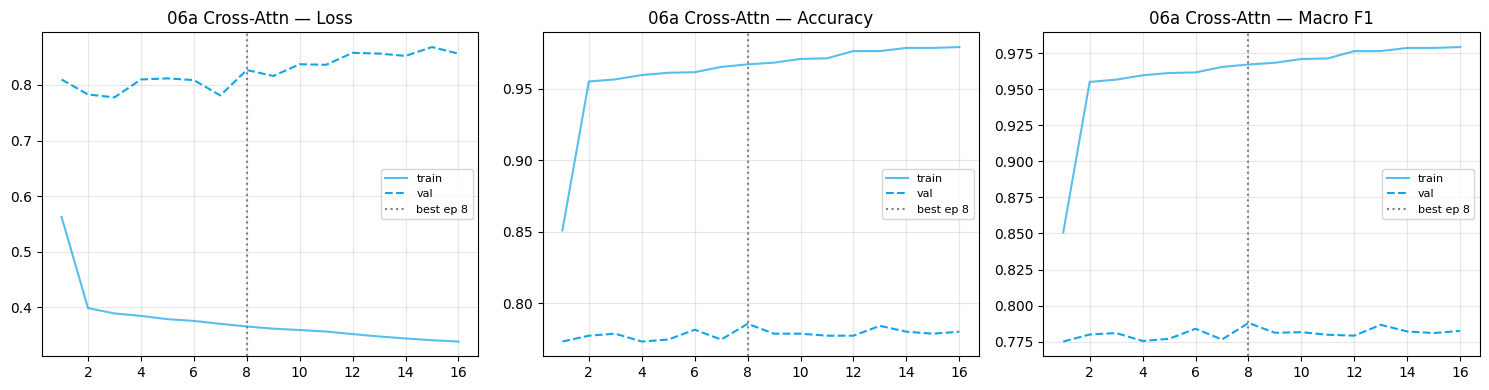

Curves saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage06a_results/20260622_210047_cross-attn_phobert768-coolant64_3cls_bs32_lr3e-4_curves.png


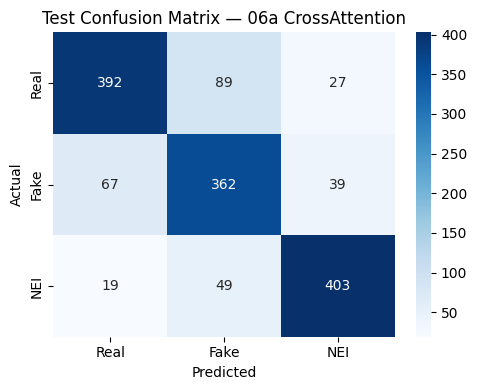

Confusion matrix saved: /Users/haila/Library/CloudStorage/GoogleDrive-latruonghai@gmail.com/My Drive/Thesis_Final/fake-news-data-for-thesis/training/stage06a_results/20260622_210047_cross-attn_phobert768-coolant64_3cls_bs32_lr3e-4_confusion_matrix.png


In [11]:
if history:
    epochs = [r["epoch"] for r in history]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    color = "#0EA5E9"
    for ax, (tr_k, vl_k, title) in zip(
        axes,
        [
            ("train_loss", "val_loss", "Loss"),
            ("train_accuracy", "val_accuracy", "Accuracy"),
            ("train_macro_f1", "val_macro_f1", "Macro F1"),
        ],
    ):
        ax.plot(
            epochs, [r[tr_k] for r in history], label="train", color=color, alpha=0.7
        )
        ax.plot(
            epochs, [r[vl_k] for r in history], label="val", color=color, linestyle="--"
        )
        ax.axvline(
            best_epoch, color="gray", linestyle=":", label=f"best ep {best_epoch}"
        )
        ax.set_title(f"06a Cross-Attn \u2014 {title}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    p = CONFIG["paths"]["results_dir"] / f"{run_name}_curves.png"
    plt.savefig(p, dpi=120)
    plt.show()
    plt.close()
    print(f"Curves saved: {p}")

if test_m.get("confusion_matrix"):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        np.array(test_m["confusion_matrix"]),
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Real", "Fake", "NEI"],
        yticklabels=["Real", "Fake", "NEI"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Test Confusion Matrix \u2014 06a CrossAttention")
    plt.tight_layout()
    p = CONFIG["paths"]["results_dir"] / f"{run_name}_confusion_matrix.png"
    plt.savefig(p, dpi=120)
    plt.show()
    plt.close()
    print(f"Confusion matrix saved: {p}")

## Step 11: Comparison vs Baselines


In [12]:
BASELINES = {
    "05a MIL Attention": {
        "test_accuracy": None,
        "test_macro_f1": None,
        "test_f1_fake": None,
    },
    "05b Asym Gate+Residual": {
        "test_accuracy": None,
        "test_macro_f1": None,
        "test_f1_fake": None,
    },
    "05d Misinfo-Aware MIL": {
        "test_accuracy": None,
        "test_macro_f1": None,
        "test_f1_fake": None,
    },
}

# Auto-load 05a/05b/05d latest results if available
for tag, results_dir_name in [
    ("05a MIL Attention", "stage05a_results"),
    ("05b Asym Gate+Residual", "stage05b_results"),
    ("05d Misinfo-Aware MIL", "stage05d_results"),
]:
    d = DATA_ROOT / "training" / results_dir_name
    if d.exists():
        cands = sorted(
            d.glob("*_results.json"), key=lambda p: p.stat().st_mtime, reverse=True
        )
        if cands:
            with open(cands[0]) as f:
                r = json.load(f)
            tm = r.get("test_metrics", {})
            BASELINES[tag] = {
                "test_accuracy": tm.get("test_accuracy"),
                "test_macro_f1": tm.get("test_macro_f1"),
                "test_f1_fake": tm.get("test_f1_fake"),
            }
            print(f'Loaded {tag}: F1={BASELINES[tag]["test_macro_f1"]}')

print("\n" + "=" * 60)
print(f'{"Model":<28} {"Acc":>8} {"F1":>8} {"F1-Fake":>10}')
print("-" * 60)
for name, m in BASELINES.items():
    acc = f'{m["test_accuracy"]:.4f}' if m["test_accuracy"] else "  N/A  "
    f1 = f'{m["test_macro_f1"]:.4f}' if m["test_macro_f1"] else "  N/A  "
    f1fk = f'{m["test_f1_fake"]:.4f}' if m["test_f1_fake"] else "  N/A  "
    print(f"{name:<28} {acc:>8} {f1:>8} {f1fk:>10}")

our_acc = test_m.get("test_accuracy", 0)
our_f1 = test_m.get("test_macro_f1", 0)
our_fake = test_m.get("test_f1_fake", 0)
print("-" * 60)
print(
    f'{"06a Cross-Attention (ours)":<28} {our_acc:>8.4f} {our_f1:>8.4f} {our_fake:>10.4f}'
)
print("=" * 60)

Loaded 05a MIL Attention: F1=0.8023
Loaded 05b Asym Gate+Residual: F1=0.7915
Loaded 05d Misinfo-Aware MIL: F1=0.7931

Model                             Acc       F1    F1-Fake
------------------------------------------------------------
05a MIL Attention              0.8014   0.8023     0.7569
05b Asym Gate+Residual         0.7901   0.7915     0.7416
05d Misinfo-Aware MIL          0.7921   0.7931     0.7485
------------------------------------------------------------
06a Cross-Attention (ours)     0.7996   0.8002     0.7479
